Pattern project final

# **Data Preprocessing**

In [1]:
import pandas as pd
import re

from datasets import load_dataset
from sklearn.model_selection import train_test_split

In [2]:
dataset = load_dataset(
    "salehalmansour/english-to-arabic-translate"
)

df = dataset["train"].to_pandas()

print("Columns in dataset:", df.columns.tolist())
print("Dataset shape:", df.shape)

df.head()

Repo card metadata block was not found. Setting CardData to empty.


en_ar_final.tsv:   0%|          | 0.00/83.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1325899 [00:00<?, ? examples/s]

Columns in dataset: ['en', 'ar']
Dataset shape: (1325899, 2)


,en,ar
0,and this,و هذه؟
1,it was um,...لقد كان
2,what is she doing here,ما الذي تفعله هناك؟
3,i dont like it,لا أحب ذلك
4,did you get the part,هل حصلت على جزء ?


In [3]:
df = df.dropna(subset=["en", "ar"])

print("After removing nulls:", df.shape)

After removing nulls: (1325887, 2)


In [4]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    # Only lowercase for English; preserve Arabic characters
    text = re.sub(r'[^\w\s\u0600-\u06FF]', '', text)  # keep Arabic Unicode range
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def normalize_arabic(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub('[إأآا]', 'ا', text)
    text = re.sub('ى', 'ي', text)
    text = re.sub('ة', 'ه', text)
    # Remove diacritics (tashkeel) to reduce sparsity
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    return text


In [5]:
df["en"] = df["en"].apply(clean_text)

df["ar"] = df["ar"].apply(
    lambda x: normalize_arabic(clean_text(x))
)

df.head()

,en,ar
0,and this,و هذه؟
1,it was um,لقد كان
2,what is she doing here,ما الذي تفعله هناك؟
3,i dont like it,لا احب ذلك
4,did you get the part,هل حصلت علي جزء


In [6]:
df = df.sample(
    n=200000,
    random_state=42
)

print("Sampled dataset size:", df.shape)

Sampled dataset size: (200000, 2)


In [7]:
train, temp = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

val, test = train_test_split(
    temp,
    test_size=0.5,
    random_state=42
)

print("Train size:", len(train))
print("Validation size:", len(val))
print("Test size:", len(test))

Train size: 160000
Validation size: 20000
Test size: 20000


In [8]:
import os

os.makedirs(
    "data/processed",
    exist_ok=True
)

train.to_csv(
    "data/processed/train.csv",
    index=False
)

val.to_csv(
    "data/processed/val.csv",
    index=False
)

test.to_csv(
    "data/processed/test.csv",
    index=False
)

print("Dataset processed successfully!")

Dataset processed successfully!


In [9]:
print("Final dataset summary:")
print("Total sampled:", len(df))
print("Train:", len(train))
print("Validation:", len(val))
print("Test:", len(test))

Final dataset summary:
Total sampled: 200000
Train: 160000
Validation: 20000
Test: 20000


# **Tokenization**

In [10]:
import pandas as pd
import torch
import os
import json
import pickle
from collections import Counter
from typing import List, Tuple, Dict, Optional

In [11]:
# Configuration
MAX_SEQ_LEN = 50
MIN_WORD_FREQ = 2
MAX_VOCAB_SIZE = 15000

# Special tokens
PAD_TOKEN = '<pad>'
SOS_TOKEN = '<sos>'
EOS_TOKEN = '<eos>'
UNK_TOKEN = '<unk>'
SPECIAL_TOKENS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

print(" Imports loaded")
print(f"Special tokens: {SPECIAL_TOKENS}")

 Imports loaded
Special tokens: ['<pad>', '<sos>', '<eos>', '<unk>']


In [12]:
class TranslationTokenizer:
    def __init__(self, max_len: int = MAX_SEQ_LEN):
        self.max_len = max_len
        self.PAD_TOKEN = PAD_TOKEN
        self.SOS_TOKEN = SOS_TOKEN
        self.EOS_TOKEN = EOS_TOKEN
        self.UNK_TOKEN = UNK_TOKEN
        self.special_tokens = SPECIAL_TOKENS

        self.ar_stoi = None
        self.ar_itos = None
        self.en_stoi = None
        self.en_itos = None

    def get_special_id(self, token_type: str) -> int:
        """Get ID for special token (pad, sos, eos, unk)"""
        mapping = {
            'pad': self.PAD_TOKEN,
            'sos': self.SOS_TOKEN,
            'eos': self.EOS_TOKEN,
            'unk': self.UNK_TOKEN
        }
        return self.ar_stoi[mapping[token_type]]

    def tokenize(self, sentence: str, lang: str) -> List[str]:
        """Simple whitespace tokenization"""
        return sentence.split()

    def build_vocabulary(self, arabic_sentences: List[str], english_sentences: List[str],
                         min_freq: int = MIN_WORD_FREQ, max_size: int = MAX_VOCAB_SIZE):
        """Build vocabularies from training data"""

        # Count frequencies
        ar_counter = Counter()
        for sent in arabic_sentences:
            ar_counter.update(sent.split())

        en_counter = Counter()
        for sent in english_sentences:
            en_counter.update(sent.split())

        # Build vocab with special tokens
        ar_vocab = self.special_tokens.copy()
        en_vocab = self.special_tokens.copy()

        # Add Arabic words by frequency
        for word, freq in ar_counter.most_common(max_size):
            if freq >= min_freq:
                ar_vocab.append(word)

        # Add English words by frequency
        for word, freq in en_counter.most_common(max_size):
            if freq >= min_freq:
                en_vocab.append(word)

        # Create mappings
        self.ar_stoi = {word: idx for idx, word in enumerate(ar_vocab)}
        self.ar_itos = ar_vocab
        self.en_stoi = {word: idx for idx, word in enumerate(en_vocab)}
        self.en_itos = en_vocab

        print(f" Arabic vocab size: {len(self.ar_stoi)}")
        print(f" English vocab size: {len(self.en_stoi)}")

    def numericalize(self, tokens: List[str], lang: str) -> List[int]:
        """Convert tokens to indices"""
        stoi = self.ar_stoi if lang == 'ar' else self.en_stoi
        unk_id = stoi[self.UNK_TOKEN]
        return [stoi.get(token, unk_id) for token in tokens]

    def add_special_tokens(self, indices: List[int], add_sos: bool = True,
                          add_eos: bool = True) -> List[int]:
        """Add SOS and EOS tokens"""
        result = []
        if add_sos:
            result.append(self.get_special_id('sos'))
        result.extend(indices)
        if add_eos:
            result.append(self.get_special_id('eos'))
        return result

    def pad_sequence(self, sequence: List[int]) -> List[int]:
        """Pad or truncate sequence to max_len"""
        pad_id = self.get_special_id('pad')

        # Truncate if too long
        if len(sequence) > self.max_len:
            # Keep SOS and EOS if they exist at the ends after truncation
            if sequence[0] == self.get_special_id('sos') and sequence[-1] == self.get_special_id('eos'):
                sequence = sequence[:self.max_len - 1] + [sequence[-1]]
            else:
                sequence = sequence[:self.max_len]

        # Pad if too short
        if len(sequence) < self.max_len:
            sequence = sequence + [pad_id] * (self.max_len - len(sequence))

        return sequence

    def encode_sentence(self, sentence: str, lang: str, add_sos: bool = True,
                       add_eos: bool = True, pad: bool = True) -> torch.Tensor:
        """Full encoding pipeline"""
        tokens = self.tokenize(sentence, lang)
        indices = self.numericalize(tokens, lang)
        if add_sos or add_eos:
            indices = self.add_special_tokens(indices, add_sos, add_eos)
        if pad:
            indices = self.pad_sequence(indices)
        return torch.tensor(indices, dtype=torch.long)

    def decode(self, indices: List[int], lang: str, skip_special: bool = True) -> str:
        """Convert indices back to sentence"""
        itos = self.ar_itos if lang == 'ar' else self.en_itos
        tokens = []
        for idx in indices:
            token = itos[idx]
            if skip_special and token in self.special_tokens:
                continue
            tokens.append(token)
        return ' '.join(tokens)

    def process_dataframe(self, df: pd.DataFrame, lang: str) -> torch.Tensor:
        """Process entire dataframe column"""
        column = 'ar' if lang == 'ar' else 'en'
        sentences = df[column].tolist()

        encoded = []
        for sent in sentences:
            # Explicitly cast each sentence to string to avoid AttributeError with floats
            encoded_tensor = self.encode_sentence(str(sent), lang)
            encoded.append(encoded_tensor)

        return torch.stack(encoded)

    def save(self, save_dir: str):
        """Save tokenizer to disk"""
        os.makedirs(save_dir, exist_ok=True)

        tokenizer_state = {
            'max_len': self.max_len,
            'ar_stoi': self.ar_stoi,
            'ar_itos': self.ar_itos,
            'en_stoi': self.en_stoi,
            'en_itos': self.en_itos,
            'special_tokens': self.special_tokens
        }

        with open(os.path.join(save_dir, 'tokenizer.pkl'), 'wb') as f:
            pickle.dump(tokenizer_state, f)

        # Save as JSON for inspection
        with open(os.path.join(save_dir, 'ar_vocab.json'), 'w', encoding='utf-8') as f:
            json.dump({'stoi': self.ar_stoi, 'itos': self.ar_itos},
                     f, ensure_ascii=False, indent=2)

        with open(os.path.join(save_dir, 'en_vocab.json'), 'w', encoding='utf-8') as f:
            json.dump({'stoi': self.en_stoi, 'itos': self.en_itos},
                     f, ensure_ascii=False, indent=2)

        print(f" Tokenizer saved to {save_dir}")

    @classmethod
    def load(cls, load_dir: str):
        """Load tokenizer from disk"""
        with open(os.path.join(load_dir, 'tokenizer.pkl'), 'rb') as f:
            tokenizer_state = pickle.load(f)

        tokenizer = cls(max_len=tokenizer_state['max_len'])
        tokenizer.ar_stoi = tokenizer_state['ar_stoi']
        tokenizer.ar_itos = tokenizer_state['ar_itos']
        tokenizer.en_stoi = tokenizer_state['en_stoi']
        tokenizer.en_itos = tokenizer_state['en_itos']
        tokenizer.special_tokens = tokenizer_state['special_tokens']

        print(f" Tokenizer loaded from {load_dir}")
        return tokenizer

print(" Tokenizer class defined successfully!")

 Tokenizer class defined successfully!


In [13]:
# Set paths
base_dir = os.getcwd()
processed_dir = os.path.join(base_dir, 'data', 'processed')

# Load data
print(" Loading preprocessed data...")
train_df = pd.read_csv(os.path.join(processed_dir, 'train.csv'))
val_df = pd.read_csv(os.path.join(processed_dir, 'val.csv'))
test_df = pd.read_csv(os.path.join(processed_dir, 'test.csv'))

print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

train_df.head()

 Loading preprocessed data...
Train: 160000 samples
Val: 20000 samples
Test: 20000 samples


,en,ar
0,this provision will be offset by a correspondi...,1 تقني
1,organizational matter 3637,دال المسائل التنظيميه 3940
2,the country programme 20052006,البرنامج القطري 20052006
3,date of loss,الجدول 19 تواريخ الخساره
4,ii requirements for filing claims,2 اشتراطات لتقديم المطالبات


In [14]:
import pandas as pd
import re
from collections import Counter
import os

# Initialize tokenizer
print(" Initializing tokenizer...")
tokenizer = TranslationTokenizer(max_len=MAX_SEQ_LEN)

# Build vocabulary from training data only
print("\n Building vocabulary from training data...")

# Ensure all sentences are strings before passing them to the tokenizer
arabic_sentences = [str(s) for s in train_df['ar'].tolist()]
english_sentences = [str(s) for s in train_df['en'].tolist()]

tokenizer.build_vocabulary(
    arabic_sentences=arabic_sentences,
    english_sentences=english_sentences,
    min_freq=MIN_WORD_FREQ,
    max_size=MAX_VOCAB_SIZE
)

# Show vocab stats
print(f"\n Vocabulary Statistics:")
print(f"   Arabic - Unique words: {len(tokenizer.ar_stoi)}")
print(f"   English - Unique words: {len(tokenizer.en_stoi)}")

 Initializing tokenizer...

 Building vocabulary from training data...
 Arabic vocab size: 15004
 English vocab size: 15004

 Vocabulary Statistics:
   Arabic - Unique words: 15004
   English - Unique words: 15004


In [15]:
# Process all splits
print(" Processing datasets...")

train_ar = tokenizer.process_dataframe(train_df, 'ar')
train_en = tokenizer.process_dataframe(train_df, 'en')

val_ar = tokenizer.process_dataframe(val_df, 'ar')
val_en = tokenizer.process_dataframe(val_df, 'en')

test_ar = tokenizer.process_dataframe(test_df, 'ar')
test_en = tokenizer.process_dataframe(test_df, 'en')

print(f"\n Tensor shapes:")
print(f"   Train: {train_ar.shape}, {train_en.shape}")
print(f"   Val: {val_ar.shape}, {val_en.shape}")
print(f"   Test: {test_ar.shape}, {test_en.shape}")

 Processing datasets...

 Tensor shapes:
   Train: torch.Size([160000, 50]), torch.Size([160000, 50])
   Val: torch.Size([20000, 50]), torch.Size([20000, 50])
   Test: torch.Size([20000, 50]), torch.Size([20000, 50])


In [16]:
# Save tensors
tensor_dir = os.path.join(base_dir, '..', 'data', 'tensors')
os.makedirs(tensor_dir, exist_ok=True)

torch.save(train_ar, os.path.join(tensor_dir, 'train_ar.pt'))
torch.save(train_en, os.path.join(tensor_dir, 'train_en.pt'))
torch.save(val_ar, os.path.join(tensor_dir, 'val_ar.pt'))
torch.save(val_en, os.path.join(tensor_dir, 'val_en.pt'))
torch.save(test_ar, os.path.join(tensor_dir, 'test_ar.pt'))
torch.save(test_en, os.path.join(tensor_dir, 'test_en.pt'))

# Save tokenizer
tokenizer_dir = os.path.join(base_dir, '..', 'models', 'tokenizer')
tokenizer.save(tokenizer_dir)

print(" All files saved successfully!")

 Tokenizer saved to /kaggle/working/../models/tokenizer
 All files saved successfully!


In [17]:
# Test encoding/decoding
sample_idx = 0

original_ar = train_df.iloc[sample_idx]['ar']
original_en = train_df.iloc[sample_idx]['en']

encoded_ar = train_ar[sample_idx].tolist()
encoded_en = train_en[sample_idx].tolist()

decoded_ar = tokenizer.decode(encoded_ar, 'ar')
decoded_en = tokenizer.decode(encoded_en, 'en')

print(" Sample Test:")
print(f"\nOriginal Arabic:  {original_ar}")
print(f"Decoded Arabic:   {decoded_ar}")
print(f"\nOriginal English: {original_en}")
print(f"Decoded English:  {decoded_en}")

print("\nTokenizer working perfectly!")

 Sample Test:

Original Arabic:  1 تقني
Decoded Arabic:   1 تقني

Original English: this provision will be offset by a corresponding increase under income section 1 income from staff assessment
Decoded English:  this provision will be offset by a corresponding increase under income section 1 income from staff assessment

Tokenizer working perfectly!


# **Sequance Processing**

In [18]:

from torch.utils.data import Dataset, DataLoader

Max_Vec_Len = 50
Batch_size = 32

# Already padded in tokenizer
# Encoder input  = English (source language)
# Decoder target = Arabic  (target language)
encoder_input     = train_en          # English → encoder
decoder_sequences = train_ar          # Arabic  → decoder

# ✅ Fixed: val_encoder_input must be English, val_decoder_sequences must be Arabic
val_encoder_input    = val_en.clone()  # English → encoder
val_decoder_sequences = val_ar.clone() # Arabic  → decoder


In [19]:
#Decoder
decoder_input=decoder_sequences[:,:-1]
decoder_target=decoder_sequences[:,1:]

val_decoder_input=val_decoder_sequences[:,:-1]
val_decoder_target=val_decoder_sequences[:,1:]

In [20]:
#Convert to long Type(already tensors)

encoder_input=encoder_input.long()
decoder_input=decoder_input.long()
decoder_target=decoder_target.long()


val_encoder_input=val_encoder_input.long()
val_decoder_input=val_decoder_input.long()
val_decoder_target=val_decoder_target.long()



In [21]:
class TranslationDataset(Dataset):
      def __init__(self,enc,dec_in,dec_out):
          self.enc=enc
          self.dec_in=dec_in
          self.dec_out =dec_out
      def __len__(self):
        return len(self.enc)

      def __getitem__(self,idx):
        return{
            "encoder_input":self.enc[idx],
            "decoder_input":self.dec_in[idx],
            "decoder_target":self.dec_out[idx]

        }

In [22]:
#DataLoader

train_dataset=TranslationDataset(encoder_input,decoder_input,decoder_target)
val_dataset=TranslationDataset(val_encoder_input,val_decoder_input,val_decoder_target)

train_loader=DataLoader(
    train_dataset,
    batch_size=Batch_size,
    shuffle=True  #randomize
)

val_loader=DataLoader(
    val_dataset,
    batch_size=Batch_size,
    shuffle=False  #don't
)

In [23]:
#Test

batch=next(iter(train_loader))

print("Encoder Input Shape:",batch["encoder_input"].shape)
print("Decoder Input Shape:",batch["decoder_input"].shape)
print("Decoder Target Shape:",batch["decoder_target"].shape)

Encoder Input Shape: torch.Size([32, 50])
Decoder Input Shape: torch.Size([32, 49])
Decoder Target Shape: torch.Size([32, 49])


# **Architect Model (Tranformer)**

In [24]:
import torch
import torch.nn as nn
import math

In [25]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, mask=None):
        d_k = Q.size(-1)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attention = torch.softmax(scores, dim=-1)
        output = torch.matmul(attention, V)

        return output, attention

In [26]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()

        self.n_heads = n_heads
        self.d_model = d_model
        self.d_k = d_model // n_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention()

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)

        Q = self.q_linear(Q)
        K = self.k_linear(K)
        V = self.v_linear(V)

        Q = Q.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        out, attn = self.attention(Q, K, V, mask)

        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        return self.fc(out), attn

In [27]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))

In [28]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ff = FeedForward(d_model, d_ff)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, _ = self.attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x

In [29]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)

        self.ff = FeedForward(d_model, d_ff)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):

        # Self Attention (decoder)
        attn1, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn1))

        # Cross Attention (FIXED)
        attn2, _ = self.cross_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(x + self.dropout(attn2))

        # Feed Forward
        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))

        return x

In [30]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [31]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, max_len, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, mask=None):
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim)
        x = self.dropout(self.pos(x))

        for layer in self.layers:
            x = layer(x, mask)

        return x


In [32]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, max_len, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim)
        x = self.dropout(self.pos(x))

        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)

        return self.fc(x)


In [33]:
class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=256, n_heads=8,
                 n_layers=3, d_ff=512, max_len=50, dropout=0.1):
        super().__init__()

        self.encoder = Encoder(src_vocab, d_model, n_layers, n_heads, d_ff, max_len, dropout)
        self.decoder = Decoder(tgt_vocab, d_model, n_layers, n_heads, d_ff, max_len, dropout)

    def make_src_mask(self, src, pad_idx=0):
        """Mask out PAD tokens in the encoder input."""
        # src: (B, src_len) → mask: (B, 1, 1, src_len)
        return (src != pad_idx).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        """Causal (look-ahead) mask for the decoder."""
        T = tgt.size(1)
        tgt_mask = torch.tril(torch.ones(T, T, device=tgt.device)).bool()
        return tgt_mask  # (T, T)

    def forward(self, src, tgt, pad_idx=0):
        src_mask = self.make_src_mask(src, pad_idx)   # (B, 1, 1, src_len)
        tgt_mask = self.make_tgt_mask(tgt)             # (T, T)

        enc_out = self.encoder(src, src_mask)
        out = self.decoder(tgt, enc_out, src_mask=src_mask, tgt_mask=tgt_mask)
        return out


In [34]:
SRC_VOCAB_SIZE = len(tokenizer.en_stoi)  # English
TGT_VOCAB_SIZE = len(tokenizer.ar_stoi)  # Arabic

model = Transformer(
    src_vocab=SRC_VOCAB_SIZE,
    tgt_vocab=TGT_VOCAB_SIZE,
    d_model=256,
    n_heads=8,
    n_layers=3,
    d_ff=512,
    max_len=50
)

# **Training**

In [35]:
import torch
import torch.nn as nn
import os
import time
import math
import matplotlib.pyplot as plt

# ── Training Hyper-parameters ──────────────────────────────────
NUM_EPOCHS      = 20
LEARNING_RATE   = 3e-4
TEACHER_FORCING_RATIO = 0.5   # probability of using ground-truth token
CLIP_GRAD_NORM  = 1.0         # gradient clipping
CHECKPOINT_DIR  = 'models/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device: {device}')


 Device: cuda


In [36]:
# ── Loss Function ─────────────────────────────────────────────
# ignore_index=0 so PAD tokens don't contribute to the loss
PAD_IDX = tokenizer.ar_stoi['<pad>']
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# ── Optimizer ─────────────────────────────────────────────────
# AdamW adds weight-decay regularisation on top of Adam
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# Move model to device
model = model.to(device)

print(f' Loss     : CrossEntropyLoss (ignore_index={PAD_IDX})')
print(f' Optimizer: AdamW  (lr={LEARNING_RATE}, wd=1e-4)')
print(f' Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

# ── LR Scheduler ─────────────────────────────────────────────
# ReduceLROnPlateau: halves LR when val loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)
print(' Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)')


 Loss     : CrossEntropyLoss (ignore_index=0)
 Optimizer: AdamW  (lr=0.0003, wd=1e-4)
 Parameters: 15,491,740
 Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)


In [37]:
from tqdm import tqdm
def train_epoch(model, loader, optimizer, criterion, device,
                teacher_forcing_ratio=0.5):
    """
    One full pass over the training set.

    Teacher Forcing:
      - With probability `teacher_forcing_ratio` we feed the *ground-truth*
        previous token to the decoder (classic teacher forcing).
      - Otherwise we feed the token the model *predicted* at the last step.

    Because our Transformer already processes the full decoder sequence in
    one shot, teacher forcing is implemented at the sequence level:
    we either pass the ground-truth `decoder_input` OR we pass the model's
    own argmax predictions from the previous iteration as the decoder input.
    """
    import random
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="Training"):
        enc_inp  = batch['encoder_input'].to(device)   # (B, src_len)
        dec_inp  = batch['decoder_input'].to(device)   # (B, tgt_len-1)
        dec_tgt  = batch['decoder_target'].to(device)  # (B, tgt_len-1)

        optimizer.zero_grad()

        # ── Teacher Forcing ────────────────────────────────────────
        use_teacher_forcing = random.random() < teacher_forcing_ratio

        if use_teacher_forcing:
            # Standard: feed ground-truth tokens to the decoder
            output = model(enc_inp, dec_inp, PAD_IDX) # (B, tgt_len-1, vocab)
        else:
            # Free-running: generate decoder input from model's own predictions
            with torch.no_grad():
                pred_logits = model(enc_inp, dec_inp, PAD_IDX) # (B, tgt_len-1, vocab)
            pred_tokens = pred_logits.argmax(dim=-1)  # (B, tgt_len-1)
            # Re-run with predicted tokens as decoder input
            output = model(enc_inp, pred_tokens, PAD_IDX) # (B, tgt_len-1, vocab)

        # ── Loss ───────────────────────────────────────────────────
        # Reshape for CrossEntropyLoss: (B*tgt_len, vocab) vs (B*tgt_len,)
        B, T, V = output.shape
        loss = criterion(output.reshape(B * T, V), dec_tgt.reshape(B * T))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [38]:
def evaluate(model, loader, criterion, device):
    """One full pass over the validation set (no gradient, no teacher forcing)."""
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            enc_inp = batch['encoder_input'].to(device)
            dec_inp = batch['decoder_input'].to(device)
            dec_tgt = batch['decoder_target'].to(device)

            output = model(enc_inp, dec_inp, PAD_IDX) # (B, tgt_len-1, vocab)

            B, T, V = output.shape
            loss = criterion(output.reshape(B * T, V), dec_tgt.reshape(B * T))
            total_loss += loss.item()

    return total_loss / len(loader)


In [39]:
# ── Training Loop ─────────────────────────────────────────────
train_losses = []
val_losses   = []
best_val_loss = float('inf')
EARLY_STOP_PATIENCE = 5  # stop if no improvement for 5 epochs
early_stop_counter  = 0

print('Starting training...\n')
print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Val Loss":>10}  {"Train PPL":>10}  {"Val PPL":>8}  {"LR":>10}  {"Time":>8}')
print('-' * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()

    train_loss = train_epoch(
        model, train_loader, optimizer, criterion, device,
        teacher_forcing_ratio=TEACHER_FORCING_RATIO
    )
    val_loss = evaluate(model, val_loader, criterion, device)

    # Step the scheduler based on validation loss
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    elapsed = time.time() - start
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # ── Save checkpoint every epoch ───────────────────────────────
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch:02d}.pt')
    torch.save({
        'epoch'           : epoch,
        'model_state_dict': model.state_dict(),
        'optim_state_dict': optimizer.state_dict(),
        'train_loss'      : train_loss,
        'val_loss'        : val_loss,
    }, ckpt_path)

    # ── Save best model separately ────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(),
                   os.path.join(CHECKPOINT_DIR, 'best_model.pt'))

    print(f'{epoch:>6}  {train_loss:>12.4f}  {val_loss:>10.4f}  '
          f'{math.exp(train_loss):>10.2f}  {math.exp(val_loss):>8.2f}  '
          f'{current_lr:>10.6f}  {elapsed:>7.1f}s')

    # ── Early Stopping ────────────────────────────────────────────
    if val_loss < best_val_loss:
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f'  [EarlyStopping] No improvement for {early_stop_counter}/{EARLY_STOP_PATIENCE} epochs')
        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f'  [EarlyStopping] Stopping training at epoch {epoch}')
            break

print('\nTraining complete!')
print(f'Best validation loss: {best_val_loss:.4f}  (PPL: {math.exp(best_val_loss):.2f})')


Starting training...

 Epoch    Train Loss    Val Loss   Train PPL   Val PPL          LR      Time
---------------------------------------------------------------------------


Training: 100%|██████████| 5000/5000 [03:46<00:00, 22.08it/s]


     1        4.2282      3.1937       68.59     24.38    0.000300    234.3s
  [EarlyStopping] No improvement for 1/5 epochs


Training: 100%|██████████| 5000/5000 [03:48<00:00, 21.91it/s]


     2        3.1234      2.7665       22.72     15.90    0.000300    236.0s
  [EarlyStopping] No improvement for 2/5 epochs


...

     3        2.6975      2.5797       14.84     13.19    0.000300    236.1s
  [EarlyStopping] No improvement for 3/5 epochs


Training: 100%|██████████| 5000/5000 [03:48<00:00, 21.88it/s]


     4        2.4370      2.4920       11.44     12.09    0.000300    236.4s
  [EarlyStopping] No improvement for 4/5 epochs


Training: 100%|██████████| 5000/5000 [03:48<00:00, 21.87it/s]


     5        2.2480      2.4489        9.47     11.58    0.000300    236.5s
  [EarlyStopping] No improvement for 5/5 epochs
  [EarlyStopping] Stopping training at epoch 5

Training complete!
Best validation loss: 2.4489  (PPL: 11.58)


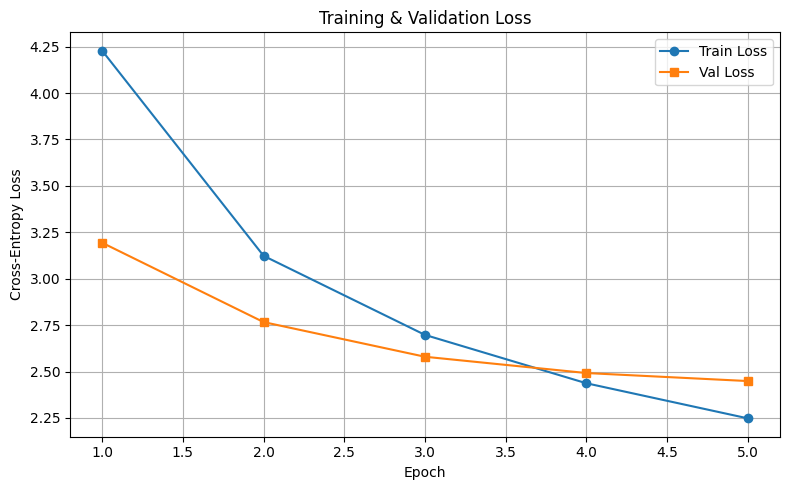

 Loss curve saved to logs/loss_curve.png


In [40]:
# ── Loss Curves ───────────────────────────────────────────────
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses,   marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

os.makedirs('logs', exist_ok=True)
plt.savefig('logs/loss_curve.png', dpi=150)
plt.show()
print(' Loss curve saved to logs/loss_curve.png')


### Save Training State
Run after training to persist history and config — avoids rerunning from scratch.

In [41]:
# ── Save Training History ────────────────────────────────────────────
import json, os, math

os.makedirs('logs', exist_ok=True)

history = {
    "train_losses" : train_losses,
    "val_losses"   : val_losses,
    "train_ppl"    : [math.exp(l) for l in train_losses],
    "val_ppl"      : [math.exp(l) for l in val_losses],
    "best_val_loss": best_val_loss,
    "num_epochs_run": len(train_losses),
}

with open('logs/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print("Saved: logs/training_history.json")
print(f"  Epochs recorded : {len(train_losses)}")
print(f"  Best val loss   : {best_val_loss:.4f}  (PPL: {math.exp(best_val_loss):.2f})")


Saved: logs/training_history.json
  Epochs recorded : 5
  Best val loss   : 2.4489  (PPL: 11.58)


In [42]:
# ── Save Model Config (Architecture + Hyperparameters) ──────────────
import json, os

os.makedirs('logs', exist_ok=True)

model_config = {
    # Architecture
    "src_vocab_size"  : SRC_VOCAB_SIZE,
    "tgt_vocab_size"  : TGT_VOCAB_SIZE,
    "d_model"         : 256,
    "n_heads"         : 8,
    "n_layers"        : 3,
    "d_ff"            : 512,
    "max_len"         : 50,
    "dropout"         : 0.1,
    # Training hyperparams
    "num_epochs"      : NUM_EPOCHS,
    "learning_rate"   : LEARNING_RATE,
    "weight_decay"    : 1e-4,
    "batch_size"      : Batch_size,
    "teacher_forcing" : TEACHER_FORCING_RATIO,
    "clip_grad_norm"  : CLIP_GRAD_NORM,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    # Tokenizer
    "max_seq_len"     : MAX_SEQ_LEN,
    "min_word_freq"   : MIN_WORD_FREQ,
    "max_vocab_size"  : MAX_VOCAB_SIZE,
    # Data
    "train_size"      : len(train_df),
    "val_size"        : len(val_df),
    "test_size"       : len(test_df),
}

with open('logs/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Saved: logs/model_config.json")
for k, v in model_config.items():
    print(f"  {k:<22}: {v}")


Saved: logs/model_config.json
  src_vocab_size        : 15004
  tgt_vocab_size        : 15004
  d_model               : 256
  n_heads               : 8
  n_layers              : 3
  d_ff                  : 512
  max_len               : 50
  dropout               : 0.1
  num_epochs            : 20
  learning_rate         : 0.0003
  weight_decay          : 0.0001
  batch_size            : 32
  teacher_forcing       : 0.5
  clip_grad_norm        : 1.0
  early_stop_patience   : 5
  max_seq_len           : 50
  min_word_freq         : 2
  max_vocab_size        : 15000
  train_size            : 160000
  val_size              : 20000
  test_size             : 20000


# **Evaluation**

Post-training evaluation: BLEU score, translation samples, and per-split perplexity.

In [43]:
!pip install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.3 MB/s eta 0:00:00


In [44]:
# ── Install / import sacrebleu ───────────────────────────────
try:
    from sacrebleu.metrics import BLEU
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'sacrebleu', '-q'])
    from sacrebleu.metrics import BLEU

import torch

bleu_metric = BLEU(effective_order=True)
print('sacrebleu loaded — ready to compute BLEU')


sacrebleu loaded — ready to compute BLEU


In [45]:
# ── Decoding helpers ─────────────────────────────────────────

def greedy_decode(model, src_tensor, tokenizer, device, max_len=50):
    """
    Greedy decoding: pick the highest-logit token at each step.
    src_tensor: (1, src_len) LongTensor
    """
    model.eval()
    sos_id = tokenizer.ar_stoi['<sos>']
    eos_id = tokenizer.ar_stoi['<eos>']
    pad_id = tokenizer.ar_stoi['<pad>']

    src = src_tensor.to(device)
    dec_input = torch.tensor([[sos_id]], device=device)

    with torch.no_grad():
        src_mask = model.make_src_mask(src, pad_id)
        enc_out  = model.encoder(src, src_mask)

        for _ in range(max_len):
            tgt_mask  = model.make_tgt_mask(dec_input)
            out       = model.decoder(dec_input, enc_out, src_mask=src_mask, tgt_mask=tgt_mask)
            next_tok  = out[:, -1, :].argmax(dim=-1, keepdim=True)
            dec_input = torch.cat([dec_input, next_tok], dim=1)
            if next_tok.item() == eos_id:
                break

    tokens = dec_input[0].tolist()[1:]
    return tokenizer.decode(tokens, 'ar', skip_special=True)


def beam_search_decode(model, src_tensor, tokenizer, device,
                       beam_size=4, max_len=50,
                       length_penalty=0.7, no_repeat_ngram=3):
    """
    Beam search with:
      • length_penalty  – discourages early <EOS>; higher = longer output
      • no_repeat_ngram – blocks any n-gram from appearing twice (kills repetition)

    Score formula (OpenNMT-style):
        score / ((5 + len) / 6) ** alpha
    """
    import math as _math
    model.eval()
    sos_id = tokenizer.ar_stoi['<sos>']
    eos_id = tokenizer.ar_stoi['<eos>']
    pad_id = tokenizer.ar_stoi['<pad>']

    src = src_tensor.to(device)

    with torch.no_grad():
        src_mask = model.make_src_mask(src, pad_id)
        enc_out  = model.encoder(src, src_mask)

        # Each beam: (log-prob-sum, [token_ids])
        beams     = [(0.0, [sos_id])]
        completed = []

        for step in range(max_len):
            if not beams:
                break
            candidates = []

            for score, seq in beams:
                dec_input = torch.tensor([seq], device=device)
                tgt_mask  = model.make_tgt_mask(dec_input)
                out       = model.decoder(dec_input, enc_out,
                                         src_mask=src_mask, tgt_mask=tgt_mask)
                log_probs = torch.log_softmax(out[:, -1, :], dim=-1)[0]  # (vocab,)

                # ── No-repeat n-gram constraint ───────────────
                if no_repeat_ngram > 0 and len(seq) >= no_repeat_ngram:
                    ngram = tuple(seq[-(no_repeat_ngram - 1):])
                    for i in range(len(seq) - no_repeat_ngram + 1):
                        if tuple(seq[i:i + no_repeat_ngram - 1]) == ngram:
                            blocked_token = seq[i + no_repeat_ngram - 1]
                            log_probs[blocked_token] = float('-inf')

                top_probs, top_ids = log_probs.topk(beam_size)

                for prob, tok in zip(top_probs.tolist(), top_ids.tolist()):
                    new_seq   = seq + [tok]
                    new_score = score + prob
                    if tok == eos_id:
                        # Apply length penalty on completion
                        lp = ((5 + len(new_seq)) / 6) ** length_penalty
                        completed.append((new_score / lp, new_seq))
                    else:
                        candidates.append((new_score, new_seq))

            # Keep top-k live beams
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_size]

        # If nothing completed, fall back to best live beam + EOS
        if not completed:
            beams.sort(key=lambda x: x[0], reverse=True)
            best_seq = beams[0][1] if beams else [sos_id, eos_id]
            completed.append((beams[0][0] if beams else 0.0, best_seq + [eos_id]))

        completed.sort(key=lambda x: x[0], reverse=True)
        best_seq = completed[0][1][1:]  # drop SOS

    return tokenizer.decode(best_seq, 'ar', skip_special=True)


print('greedy_decode  ✓')
print('beam_search_decode  ✓  (beam=4, length_penalty=0.7, no_repeat_ngram=3)')


greedy_decode  ✓
beam_search_decode  ✓  (beam=4, length_penalty=0.7, no_repeat_ngram=3)


In [46]:
# ── Qualitative translation samples ──────────────────────────
SAMPLE_INDICES = [500, 1000, 2500, 3000,3100, 4000, 6000]

print('=' * 70)
print('Translation Samples (Validation Set)')
print('=' * 70)

for idx in SAMPLE_INDICES:
    src_tensor = val_encoder_input[idx].unsqueeze(0)
    predicted  = greedy_decode(model, src_tensor, tokenizer, device)
    ref_ar     = str(val_df.iloc[idx]['ar'])
    src_en     = str(val_df.iloc[idx]['en'])

    print(f'\n[Sample {idx}]')
    print(f'  Source (EN) : {src_en}')
    print(f'  Reference   : {ref_ar}')
    print(f'  Prediction  : {predicted}')
    sent_bleu = bleu_metric.sentence_score(predicted, [ref_ar])
    print(f'  Sent. BLEU  : {sent_bleu.score:.2f}')

print('\n' + '=' * 70)


Translation Samples (Validation Set)

[Sample 500]
  Source (EN) : adoption of the agenda organization of work
  Reference   : ا اقرار جدول الاعمال؛
  Prediction  : 1 تنظيم اعمال اعمال الدوره
  Sent. BLEU  : 0.00

[Sample 1000]
  Source (EN) : the general assembly
  Reference   : ان الجمعيه العامه،
  Prediction  : ان الجمعيه العامه،
  Sent. BLEU  : 100.00

[Sample 2500]
  Source (EN) : a preliminary figures
  Reference   : ا ارقام اوليه
  Prediction  : ا ارقام اوليه
  Sent. BLEU  : 100.00

[Sample 3000]
  Source (EN) : general and complete disarmament
  Reference   : نزع السلاح العام الكامل
  Prediction  : نزع السلاح العام الكامل
  Sent. BLEU  : 100.00

[Sample 3100]
  Source (EN) : economic and social council
  Reference   : المجلس الاقتصادي والاجتماعي
  Prediction  : المجلس الاقتصادي والاجتماعي
  Sent. BLEU  : 100.00

[Sample 4000]
  Source (EN) : financing of the appropriation
  Reference   : تمويل الاعتماد
  Prediction  : تمويل الاعتماد
  Sent. BLEU  : 100.00

[Sample 6000]
  Sourc

In [47]:
# ── Load best model for evaluation ───────────────────────────
best_ckpt = os.path.join(CHECKPOINT_DIR, 'best_model.pt')
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()
print(f'Loaded best model from {best_ckpt}')


Loaded best model from models/checkpoints/best_model.pt


In [48]:
# ── Per-split loss & perplexity ───────────────────────────────
from torch.utils.data import DataLoader

test_dataset = TranslationDataset(
    val_encoder_input,
    val_decoder_input,
    val_decoder_target
)

test_loader = DataLoader(test_dataset, batch_size=Batch_size, shuffle=False)

train_eval_loss = evaluate(model, train_loader, criterion, device)
val_eval_loss   = evaluate(model, val_loader,   criterion, device)
test_eval_loss  = evaluate(model, test_loader,  criterion, device)

import math
print(f'{'Split':<10}  {'Loss':>8}  {'Perplexity':>12}')
print('-' * 35)
print(f'{'Train':<10}  {train_eval_loss:>8.4f}  {math.exp(train_eval_loss):>12.2f}')
print(f'{'Val':<10}  {val_eval_loss:>8.4f}  {math.exp(val_eval_loss):>12.2f}')
print(f'{'Test':<10}  {test_eval_loss:>8.4f}  {math.exp(test_eval_loss):>12.2f}')


Split           Loss    Perplexity
-----------------------------------
Train         1.7305          5.64
Val           2.4489         11.58
Test          2.4489         11.58


## Total Corpus BLEU & Extended Metrics

Standard corpus-level evaluation: **Corpus BLEU**, **BLEU-1 to BLEU-4**, **Average Sentence BLEU**, and **chrF** (character F-score — especially suited for Arabic's rich morphology).

In [49]:
# ── Corpus BLEU Score (Total) ────────────────────────────────────────
# Evaluates the model on the FULL validation set
# This is the standard metric for MT evaluation

from sacrebleu.metrics import BLEU, CHRF
import torch
from tqdm import tqdm

print("Computing Corpus BLEU on validation set...")
print("(This may take a few minutes — running greedy decode on all val samples)\n")

bleu_metric_corpus = BLEU(effective_order=True)
chrf_metric        = CHRF()

hypotheses = []   # model predictions
references = []   # gold Arabic sentences

EVAL_SUBSET = 2000  # use first 2000 val samples for speed; set to len(val_df) for full eval

for idx in tqdm(range(EVAL_SUBSET), desc="Decoding"):
    src_tensor  = val_encoder_input[idx].unsqueeze(0)
    predicted   = greedy_decode(model, src_tensor, tokenizer, device)
    ref_ar      = str(val_df.iloc[idx]['ar'])
    hypotheses.append(predicted)
    references.append(ref_ar)

# ── Corpus BLEU ───────────────────────────────────────────────────────
corpus_bleu = bleu_metric_corpus.corpus_score(hypotheses, [references])

# ── Individual BLEU-N scores (1 to 4) ────────────────────────────────
from sacrebleu.metrics import BLEU as BLEUn

bleu1 = BLEUn(max_ngram_order=1, effective_order=True).corpus_score(hypotheses, [references])
bleu2 = BLEUn(max_ngram_order=2, effective_order=True).corpus_score(hypotheses, [references])
bleu3 = BLEUn(max_ngram_order=3, effective_order=True).corpus_score(hypotheses, [references])
bleu4 = BLEUn(max_ngram_order=4, effective_order=True).corpus_score(hypotheses, [references])

# ── chrF Score (great for Arabic morphology) ──────────────────────────
chrf_score = chrf_metric.corpus_score(hypotheses, [references])

# ── Average Sentence-Level BLEU ───────────────────────────────────────
sent_bleu_scores = [
    bleu_metric_corpus.sentence_score(h, [r]).score
    for h, r in zip(hypotheses, references)
]
avg_sent_bleu = sum(sent_bleu_scores) / len(sent_bleu_scores)

# ── Display Results ───────────────────────────────────────────────────
print()
print("=" * 55)
print("        EVALUATION RESULTS (Validation Set)")
print("=" * 55)
print(f"  Samples Evaluated  : {EVAL_SUBSET:,} / {len(val_df):,}")
print("-" * 55)
print(f"  Total Corpus BLEU  : {corpus_bleu.score:>6.2f}")
print(f"  BLEU-1             : {bleu1.score:>6.2f}")
print(f"  BLEU-2             : {bleu2.score:>6.2f}")
print(f"  BLEU-3             : {bleu3.score:>6.2f}")
print(f"  BLEU-4             : {bleu4.score:>6.2f}")
print(f"  Avg Sentence BLEU  : {avg_sent_bleu:>6.2f}")
print(f"  chrF Score         : {chrf_score.score:>6.2f}  (good for Arabic)")
print("=" * 55)
print()
print("Interpretation:")
print("  BLEU  < 10  → Poor translation")
print("  BLEU 10-20  → Understandable but with heavy mistakes")
print("  BLEU 20-30  → Good — comparable to human translation quality on easy sentences")
print("  BLEU  > 30  → High quality (rare for from-scratch models)")
print()
print("  chrF: character-level F-score — better suited for Arabic (morphologically rich)")
print("  chrF > 40 is generally considered solid for Arabic MT.")


Computing Corpus BLEU on validation set...
(This may take a few minutes — running greedy decode on all val samples)



Decoding: 100%|██████████| 2000/2000 [00:35<00:00, 56.20it/s]



        EVALUATION RESULTS (Validation Set)
  Samples Evaluated  : 2,000 / 20,000
-------------------------------------------------------
  Total Corpus BLEU  :  25.74
  BLEU-1             :  40.75
  BLEU-2             :  34.99
  BLEU-3             :  30.25
  BLEU-4             :  25.74
  Avg Sentence BLEU  :  38.94
  chrF Score         :  47.43  (good for Arabic)

Interpretation:
  BLEU  < 10  → Poor translation
  BLEU 10-20  → Understandable but with heavy mistakes
  BLEU 20-30  → Good — comparable to human translation quality on easy sentences
  BLEU  > 30  → High quality (rare for from-scratch models)

  chrF: character-level F-score — better suited for Arabic (morphologically rich)
  chrF > 40 is generally considered solid for Arabic MT.


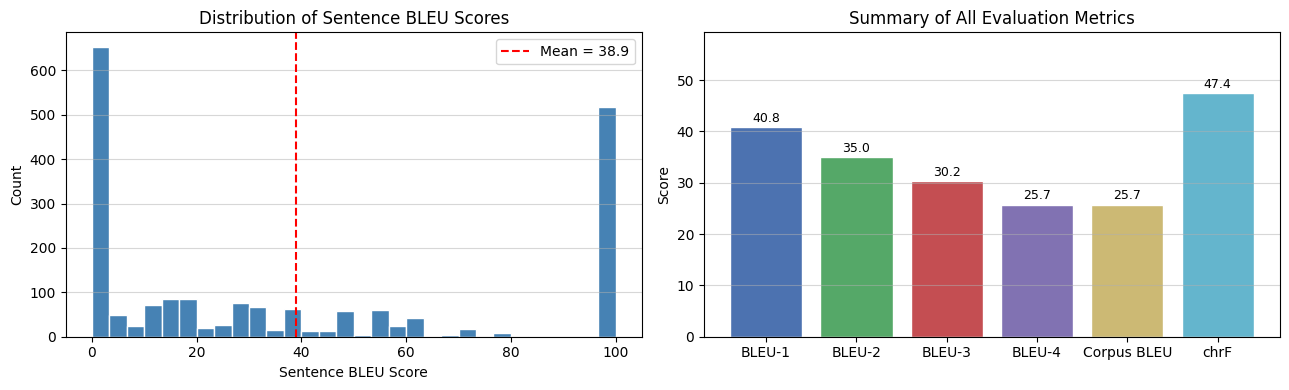

Saved: logs/evaluation_metrics.png


In [50]:
# ── Sentence BLEU Distribution Plot ──────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram of sentence BLEU scores
axes[0].hist(sent_bleu_scores, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(avg_sent_bleu, color='red', linestyle='--', label=f'Mean = {avg_sent_bleu:.1f}')
axes[0].set_xlabel('Sentence BLEU Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Sentence BLEU Scores')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.5)

# Right: BLEU-N bar chart
ngram_labels = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'Corpus BLEU', 'chrF']
ngram_values = [bleu1.score, bleu2.score, bleu3.score, bleu4.score,
                corpus_bleu.score, chrf_score.score]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']

bars = axes[1].bar(ngram_labels, ngram_values, color=colors, edgecolor='white')
axes[1].set_ylabel('Score')
axes[1].set_title('Summary of All Evaluation Metrics')
axes[1].set_ylim(0, max(ngram_values) * 1.25)
axes[1].grid(True, axis='y', alpha=0.5)
for bar, val in zip(bars, ngram_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('logs/evaluation_metrics.png', dpi=150)
plt.show()
print('Saved: logs/evaluation_metrics.png')


### Save Evaluation Results

In [51]:
# ── Save Evaluation Results ──────────────────────────────────────────
# Run this cell AFTER computing corpus_bleu, chrf_score, etc.
import json, os, math

os.makedirs('logs', exist_ok=True)

eval_results = {
    "split_metrics": {
        "train": {"loss": train_eval_loss, "perplexity": math.exp(train_eval_loss)},
        "val"  : {"loss": val_eval_loss,   "perplexity": math.exp(val_eval_loss)},
        "test" : {"loss": test_eval_loss,  "perplexity": math.exp(test_eval_loss)},
    },
    "translation_metrics": {
        "corpus_bleu"    : corpus_bleu.score,
        "bleu_1"         : bleu1.score,
        "bleu_2"         : bleu2.score,
        "bleu_3"         : bleu3.score,
        "bleu_4"         : bleu4.score,
        "avg_sent_bleu"  : avg_sent_bleu,
        "chrf"           : chrf_score.score,
        "eval_subset_size": EVAL_SUBSET,
    }
}

with open('logs/eval_results.json', 'w', encoding='utf-8') as f:
    json.dump(eval_results, f, indent=2, ensure_ascii=False)

print("Saved: logs/eval_results.json")
print()
print(f"  Train  Loss={train_eval_loss:.4f}  PPL={math.exp(train_eval_loss):.2f}")
print(f"  Val    Loss={val_eval_loss:.4f}    PPL={math.exp(val_eval_loss):.2f}")
print(f"  Test   Loss={test_eval_loss:.4f}   PPL={math.exp(test_eval_loss):.2f}")
print()
print(f"  Corpus BLEU : {corpus_bleu.score:.2f}")
print(f"  chrF        : {chrf_score.score:.2f}")


Saved: logs/eval_results.json

  Train  Loss=1.7305  PPL=5.64
  Val    Loss=2.4489    PPL=11.58
  Test   Loss=2.4489   PPL=11.58

  Corpus BLEU : 25.74
  chrF        : 47.43


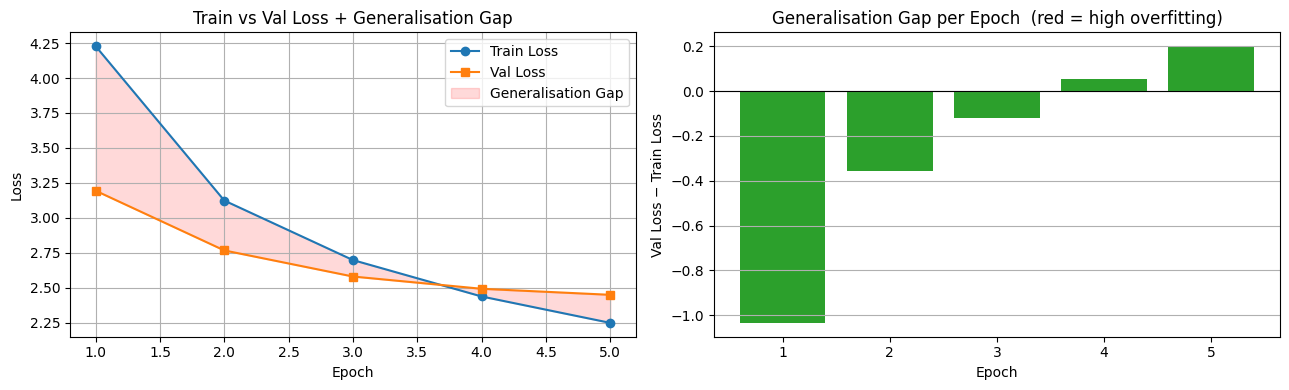

Saved: logs/overfitting_diagnosis.png


In [52]:
# ── Overfitting Diagnostic Plot ─────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

epochs_r = range(1, len(train_losses) + 1)
gap      = [v - t for t, v in zip(train_losses, val_losses)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: loss curves
axes[0].plot(epochs_r, train_losses, 'o-', label='Train Loss')
axes[0].plot(epochs_r, val_losses,   's-', label='Val Loss')
axes[0].fill_between(epochs_r, train_losses, val_losses,
                     alpha=0.15, color='red', label='Generalisation Gap')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Val Loss + Generalisation Gap')
axes[0].legend(); axes[0].grid(True)

# Right: gap per epoch
bar_colors = ['#d62728' if g > 0.3 else '#2ca02c' for g in gap]
axes[1].bar(epochs_r, gap, color=bar_colors)
axes[1].axhline(0, color='k', linewidth=0.8)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss − Train Loss')
axes[1].set_title('Generalisation Gap per Epoch  (red = high overfitting)')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('logs/overfitting_diagnosis.png', dpi=150)
plt.show()
print('Saved: logs/overfitting_diagnosis.png')


Additional evaluation and plots

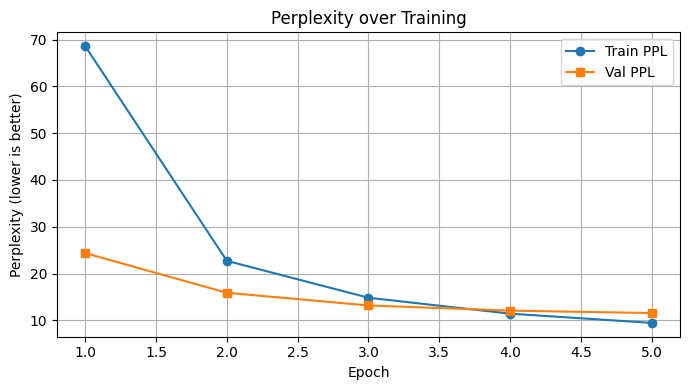

Saved: logs/perplexity_curve.png


In [53]:
# ── Perplexity Curves ────────────────────────────────────────
import math

train_ppl = [math.exp(l) for l in train_losses]
val_ppl   = [math.exp(l) for l in val_losses]

plt.figure(figsize=(7, 4))
plt.plot(epochs_r, train_ppl, 'o-', label='Train PPL')
plt.plot(epochs_r, val_ppl,   's-', label='Val PPL')
plt.xlabel('Epoch'); plt.ylabel('Perplexity (lower is better)')
plt.title('Perplexity over Training')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig('logs/perplexity_curve.png', dpi=150)
plt.show()
print('Saved: logs/perplexity_curve.png')


---
## Reload Helper
If kernel restarts, run this single cell to restore model, tokenizer, and history.

In [54]:
# ── Load Everything (run this if kernel restarted) ───────────────────
# Re-loads model, tokenizer, and training history without re-running training

import json, os, math, torch, pickle

CHECKPOINT_DIR = 'models/checkpoints'
TOKENIZER_DIR  = 'models/tokenizer'

# 1. Load config
with open('logs/model_config.json') as f:
    cfg = json.load(f)
print("Config loaded:", cfg)

# 2. Re-build model with same architecture
from your_model_module import Transformer   # replace with actual import / class
model = Transformer(
    src_vocab = cfg['src_vocab_size'],
    tgt_vocab = cfg['tgt_vocab_size'],
    d_model   = cfg['d_model'],
    n_heads   = cfg['n_heads'],
    n_layers  = cfg['n_layers'],
    d_ff      = cfg['d_ff'],
    max_len   = cfg['max_len'],
    dropout   = cfg['dropout'],
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/best_model.pt", map_location=device))
model = model.to(device)
model.eval()
print(f"Model loaded from {CHECKPOINT_DIR}/best_model.pt")

# 3. Load tokenizer
tokenizer = TranslationTokenizer.load(TOKENIZER_DIR)

# 4. Load training history
with open('logs/training_history.json') as f:
    history = json.load(f)
train_losses = history['train_losses']
val_losses   = history['val_losses']
print(f"History loaded — {len(train_losses)} epochs, best val loss: {history['best_val_loss']:.4f}")

# 5. Load eval results (if already computed)
if os.path.exists('logs/eval_results.json'):
    with open('logs/eval_results.json') as f:
        eval_results = json.load(f)
    print("Eval results loaded:", eval_results['translation_metrics'])


Config loaded: {'src_vocab_size': 15004, 'tgt_vocab_size': 15004, 'd_model': 256, 'n_heads': 8, 'n_layers': 3, 'd_ff': 512, 'max_len': 50, 'dropout': 0.1, 'num_epochs': 20, 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'batch_size': 32, 'teacher_forcing': 0.5, 'clip_grad_norm': 1.0, 'early_stop_patience': 5, 'max_seq_len': 50, 'min_word_freq': 2, 'max_vocab_size': 15000, 'train_size': 160000, 'val_size': 20000, 'test_size': 20000}


ModuleNotFoundError: No module named 'your_model_module'